In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from studio_preprocessing_tools import *

## Loading PafA data (ALPH_ELIME_Markin_2021)

In [2]:
wt_seq = "MLTPKKWLLGVLVVSGMLGAQKTNAVPRPKLVVGLVVDQMRWDYLYRYYSKYGEGGFKRMLNTGYSLNNVHIDYVPTVTAIGHTSIFTGSVPSIHGIAGNDWYDKELGKSVYCTSDETVQPVGTTSNSVGQHSPRNLWSTTVTDQLGLATNFTSKVVGVSLKDRASILPAGHNPTGAFWFDDTTGKFITSTYYTKELPKWVNDFNNKNVPAQLVANGWNTLLPINQYTESSEDNVEWEGLLGSKKTPTFPYTDLAKDYEAKKGLIRTTPFGNTLTLQMADAAIDGNQMGVDDITDFLTVNLASTDYVGHNFGPNSIEVEDTYLRLDRDLADFFNNLDKKVGKGNYLVFLSADHGAAHSVGFMQAHKMPTGFFVEDMKKEMNAKLKQKFGADNIIAAAMNYQVYFDRKVLADSKLELDDVRDYVMTELKKEPSVLYVLSTDEIWESSIPEPIKSRVINGYNWKRSGDIQIISKDGYLSAYSKKGTTHSVWNSYDSHIPLLFMGWGIKQGESNQPYHMTDIAPTVSSLLKIQFPSGAVGKPITEVIGR"
print(f'Length of sequence: {len(wt_seq)}')

raw_data = pd.read_csv("../../pg2/DMS_assays/raw_data/Markin_2021/Markin_2021.csv").set_index("variant")

# Checking that the WT sequence matches the DMS names
seq = get_raw_sequence_from_df_ids(raw_data)
first_pos_in_dms = seq.rfind('_')+1
assert seq[first_pos_in_dms:] == wt_seq[first_pos_in_dms:]

y1 = 'kcatOverKM_MeP_M-1s-1'
y2 = 'kcatOverKM_cMUP_M-1s-1'

Length of sequence: 546
Identified maximum mutated position of 546, using as sequence length


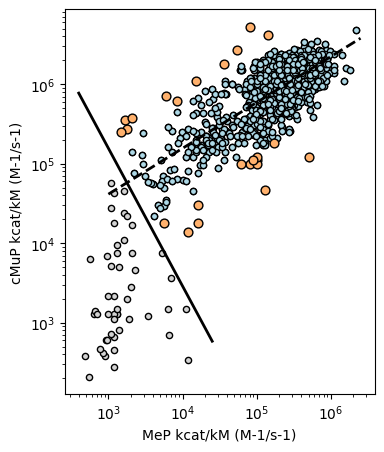

In [3]:
plt.figure(figsize=(4,5))

plt.scatter(raw_data['kcatOverKM_MeP_M-1s-1'], raw_data['kcatOverKM_cMUP_M-1s-1'], ec='k', c='lightgray', s=20)
plt.xscale('log'); plt.yscale('log')

raw_data_filt = raw_data.loc[(raw_data[y1]>5000)&(raw_data[y2]>20000)]
m, b, r, p, _ = linregress(np.log10(raw_data_filt[y1]), np.log10(raw_data_filt[y2]))
x = np.arange(3,6.5, 0.1)

x2 = np.arange(2.6,4.5, 0.1)
m_perp, b_perp = perpendicular_line(m, b, 3.25)

plt.plot(10**x, 10**(m*x + b), c='k', lw=2, ls='--')

intersections, d = perpendicular_intersection_and_distance(m, b, np.log10(raw_data[y1]), np.log10(raw_data[y2]))

x_coord_intersections = intersections[0]
d_active = d[x_coord_intersections>3.3]

raw_data_active = raw_data.loc[x_coord_intersections>3.3]
plt.scatter(raw_data_active['kcatOverKM_MeP_M-1s-1'], raw_data_active['kcatOverKM_cMUP_M-1s-1'], ec='k', c='lightblue', s=20)

specificity_mutations = raw_data_active.loc[d_active>0.55]

plt.scatter(specificity_mutations['kcatOverKM_MeP_M-1s-1'], specificity_mutations['kcatOverKM_cMUP_M-1s-1'], ec='k', c='xkcd:apricot', s=40)

plt.plot(10**x2, 10**(x2*m_perp + b_perp), c='k', lw=2)

plt.xlabel('MeP kcat/kM (M-1/s-1)')
plt.ylabel('cMuP kcat/kM (M-1/s-1)')

plt.xscale('log'); plt.yscale('log')

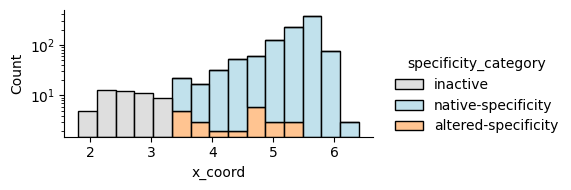

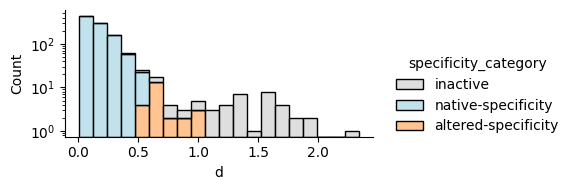

In [4]:
df = assign_specificity_categories(raw_data,
                              lambda index,row:x_coord_intersections.loc[index]<3.3,
                              lambda index,row:d.loc[index]>0.55)

df = pd.concat([df, x_coord_intersections.rename("x_coord"), d.rename("d")],axis=1)

sns.displot(data=df, x="x_coord", hue="specificity_category", multiple='stack', 
            palette={'native-specificity': 'lightblue', 'inactive':'lightgray', 'altered-specificity':'xkcd:apricot'},
            height=2, aspect=2, bins=15, hue_order=("inactive", "native-specificity", "altered-specificity"))

plt.yscale('log')

# Get current axes and y-limits
ax = plt.gca()
ylim = ax.get_ylim()
ymin = ylim[0]

# Truncate all bar patches
for patch in ax.patches:
    # Get current bar position and height
    bbox = patch.get_bbox()
    x0, y0, x1, y1 = bbox.x0, bbox.y0, bbox.x1, bbox.y1
    
    # If bar extends below ymin, truncate it
    if y0 < ymin:
        patch.set_y(ymin)
        patch.set_height(y1 - ymin)

plt.savefig('histogram_x_coord.pdf', bbox_inches='tight')

sns.displot(data=df, x="d", hue="specificity_category", multiple='stack', 
            palette={'native-specificity': 'lightblue', 'inactive':'lightgray', 'altered-specificity':'xkcd:apricot'},
            height=2, aspect=2, bins=20, hue_order=("inactive", "native-specificity", "altered-specificity"))

plt.yscale('log')

# Get current axes and y-limits
ax = plt.gca()
ylim = ax.get_ylim()
ymin = ylim[0]

# Truncate all bar patches
for patch in ax.patches:
    # Get current bar position and height
    bbox = patch.get_bbox()
    x0, y0, x1, y1 = bbox.x0, bbox.y0, bbox.x1, bbox.y1
    
    # If bar extends below ymin, truncate it
    if y0 < ymin:
        patch.set_y(ymin)
        patch.set_height(y1 - ymin)

plt.savefig('histogram_d.pdf', bbox_inches='tight')

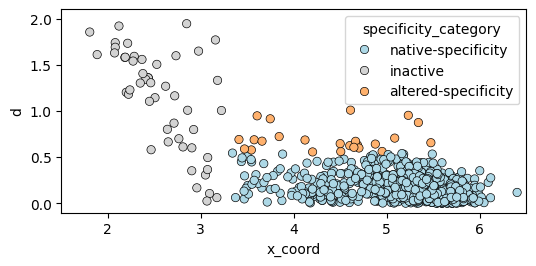

In [5]:
plt.figure(figsize=(6,0.44*6))
sns.scatterplot(data=df, x='x_coord', y='d', hue="specificity_category", ec='k', palette=gentle_palette)
plt.xlim(1.5, 6.5)
plt.ylim(-0.1, 2.1)

plt.savefig("PafA_specificity_scatterplot.pdf", bbox_inches='tight')

In [6]:
df = assign_mutant_column(df)
df['n_subs'] = [i.count(':')+1 if i!='M1M' else 0 for i in df.mutant]
df['mutated_sequence'] = [apply_mutations(wt_seq, muts) for muts in df.mutant]
df['DMS_score'] = df['kcatOverKM_MeP_M-1s-1'].copy()

In [7]:
df_singles = selector(df, {'n_subs':1})
df_singles['pos'] = [int(i[1:-1]) for i in df_singles['mutant']]
df_singles['altered-specificity'] = df_singles['specificity_category']=='altered-specificity'

In [8]:
mean_altsp = df_singles.groupby('pos').mean('altered-specificity')['altered-specificity']
altsp = mean_altsp.loc[mean_altsp>0]

In [9]:
altsp.index

Index([ 38,  39,  78,  86,  95, 100, 111, 114, 119, 152, 164, 168, 178, 182,
       299, 304, 306, 352, 386, 405, 464, 473, 518],
      dtype='int64', name='pos')

In [10]:
def get_specificity_positions(df):
    sp_muts = selector(df, {'specificity_category': 'altered-specificity', 'n_subs':1}).mutant
    return pd.Series([i[1:-1] for i in sp_muts]).value_counts()

print(f"create PafA_specificity, PafA and name CA and resi {'+'.join([str(i) for i in altsp.index])}")

for pos,n in altsp.items():
    print(f"set sphere_scale, {n*2}, PafA_specificity and res {pos};")

create PafA_specificity, PafA and name CA and resi 38+39+78+86+95+100+111+114+119+152+164+168+178+182+299+304+306+352+386+405+464+473+518
set sphere_scale, 1.0, PafA_specificity and res 38;
set sphere_scale, 1.0, PafA_specificity and res 39;
set sphere_scale, 1.0, PafA_specificity and res 78;
set sphere_scale, 1.0, PafA_specificity and res 86;
set sphere_scale, 1.0, PafA_specificity and res 95;
set sphere_scale, 1.3333333333333333, PafA_specificity and res 100;
set sphere_scale, 1.0, PafA_specificity and res 111;
set sphere_scale, 1.0, PafA_specificity and res 114;
set sphere_scale, 1.0, PafA_specificity and res 119;
set sphere_scale, 1.0, PafA_specificity and res 152;
set sphere_scale, 0.6666666666666666, PafA_specificity and res 164;
set sphere_scale, 1.0, PafA_specificity and res 168;
set sphere_scale, 1.0, PafA_specificity and res 178;
set sphere_scale, 1.0, PafA_specificity and res 182;
set sphere_scale, 1.0, PafA_specificity and res 299;
set sphere_scale, 1.0, PafA_specificity an

In [11]:
print(df.shape)

check_dataset(df)

(1042, 41)
Checking dataset table:
✅ DMS_score in table
✅ mutated_sequence in table
✅ mutant in table
✅ Contains WT sequence (M1M)
✅ all mutants pass checks and match sequence

✅ All checks passed!


In [12]:
df.to_csv("../../processed_data/ALPH_ELIME_Markin_2021.csv")

In [14]:
np.savetxt('../../processed_data/pafa_ESCOTT.mut', df.mutant.values, fmt="%s")
np.savetxt('../../processed_data/pafa_GEMME.mut', [i.replace(':',',') for i in df.mutant.values], fmt="%s")